## Метрики якості моделі

In [1]:
import numpy as np


#### Regression

In [7]:
from sklearn.metrics import mean_squared_error

y_true = [3, -0.5, 2, 7]
y_pred = [2.5, 0.0, 2, 8]
MSE = mean_squared_error(y_true, y_pred)
MSE

0.375

#### Root mean squared error (RMSE)


Увага! Цей функціонал складніше мінімізувати, тому що у модуля похідна не існує в нулі.

In [11]:
from sklearn.metrics import root_mean_squared_error

RMSE = root_mean_squared_error(y_true, y_pred)
RMSE

2.1360009363293826

In [12]:
import math
RMSE == math.sqrt(MSE)

False

In [13]:
# if differences are larger than 1
y_true = [3, -0.5, 2, 7]
y_pred = [1, 2.0,4,9]

RSME = root_mean_squared_error(y_true, y_pred)
RSME

2.1360009363293826

In [14]:
MSE = mean_squared_error(y_true, y_pred)
MSE

4.5625

#### Mean absolute error (MAE)

Увага! Цей функціонал складніше мінімізувати, тому що у модуля похідна не існує в нулі.

In [15]:
from sklearn.metrics import mean_absolute_error

MAE = mean_absolute_error(y_true, y_pred)
MAE

2.125

#### R2 score

In [16]:
from sklearn.metrics import r2_score

y_true = [3, -0.5, 2, 7]
y_pred = [1, 2.0, 4, 9]

r2 = r2_score(y_true, y_pred)
r2

0.37473233404710926

0.21428571428571427

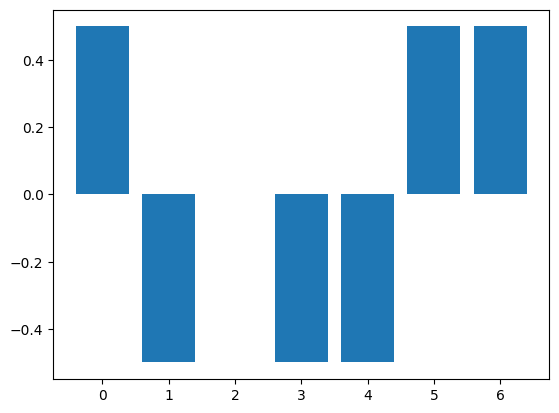

In [17]:
from sklearn.metrics import mean_pinball_loss
import matplotlib.pyplot as plt

x = [0, 1, 2 ,3, 4, 5, 6]
y_true = np.array([3, -0.5, 2, 7, 5, 6, 7])
y_pred = np.array([2.5, 0.0, 2, 7.5, 5.5, 5.5, 6.5])
diff = y_true - y_pred
plt.bar(x, height=diff)
mean_pinball_loss(y_true, y_pred, alpha=0.25)
# чим нижчий альфа, тим сильніше ми штрайуємо перепрогрноз

In [18]:
# деякі моделі дозволяють використовувати квантильної похибки
from sklearn.ensemble import GradientBoostingRegressor

GradientBoostingRegressor(loss='quantile')

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'quantile'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child

### Classification

#### Accuracy

In [19]:
from sklearn.metrics import accuracy_score

y_pred = [1, 2, 2, 3]
y_true = [0, 1, 2, 3]

accuracy_score(y_true, y_pred)

0.5

Problem 1: Imbalanced data

In [20]:
y_pred = [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
y_true = [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

accuracy_score(y_true, y_pred)

0.9333333333333333

Probem 2: wieght of mistake